In [1]:
import cv2
import skimage
import sklearn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.morphology import closing, opening, disk, remove_small_holes, remove_small_objects, binary_dilation

In [2]:
from utils import find_active_player, apply_rgb_threshold, extract_and_normalize_card, classify_card_color, detect_card_contours, find_central_card, apply_opening

Dimensiones de una carta: 350x540px

In [3]:
import os
from pathlib import Path

# Set paths
project_root = Path("./")
train_images_dir = project_root / "train_images"
test_images_dir = project_root / "test_images"

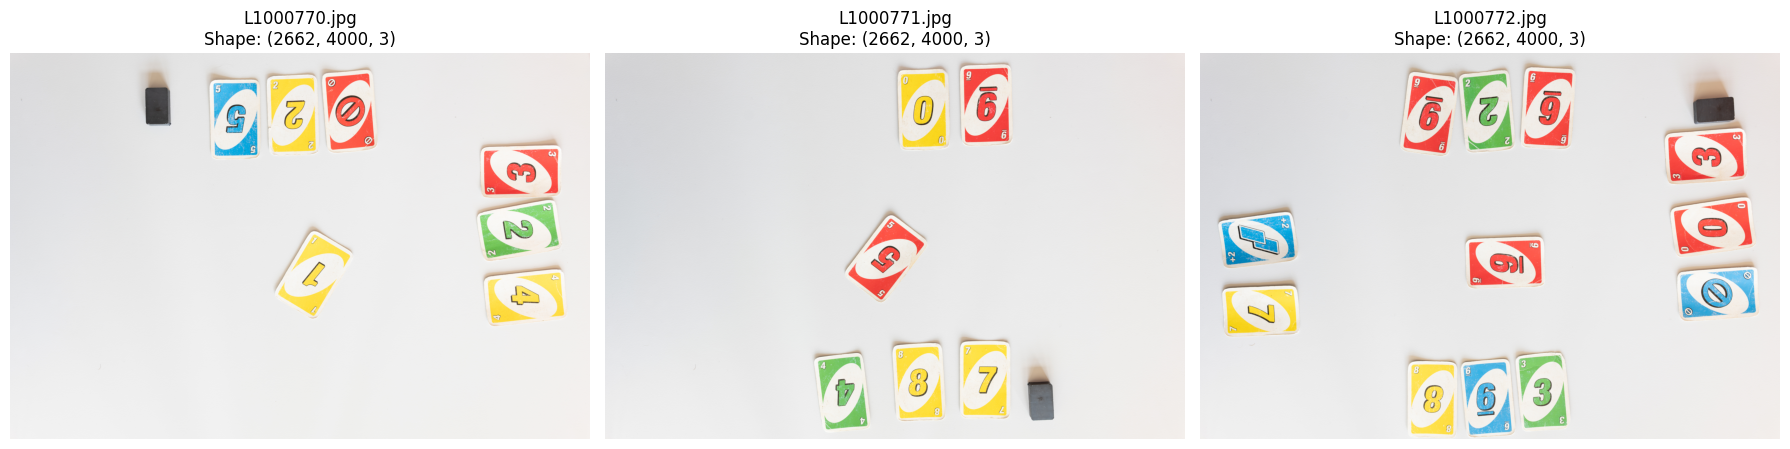

Sample image loaded. Shape: (2662, 4000, 3)
Image dimensions suggest: Height=2662px, Width=4000px


In [4]:
def load_and_display_samples(num_samples=3):
    """Load and display sample images"""
    image_files = sorted(list(train_images_dir.glob("*.jpg")))[:num_samples]
    
    fig, axes = plt.subplots(1, num_samples, figsize=(18, 6))
    
    for idx, img_path in enumerate(image_files):
        img = np.array(Image.open(img_path))
        axes[idx].imshow(img)
        axes[idx].set_title(f"{img_path.name}\nShape: {img.shape}")
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Sample image loaded. Shape: {np.array(Image.open(image_files[0])).shape}")
    print(f"Image dimensions suggest: Height={np.array(Image.open(image_files[0])).shape[0]}px, Width={np.array(Image.open(image_files[0])).shape[1]}px")

load_and_display_samples(3)

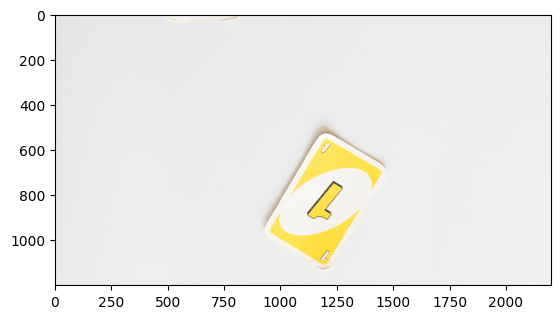

In [13]:
sample_img_path = list(train_images_dir.glob("*.jpg"))[0]
img = np.array(Image.open(sample_img_path))
sample_img = img[700:1900, 900:3100, :]
plt.imshow(sample_img)

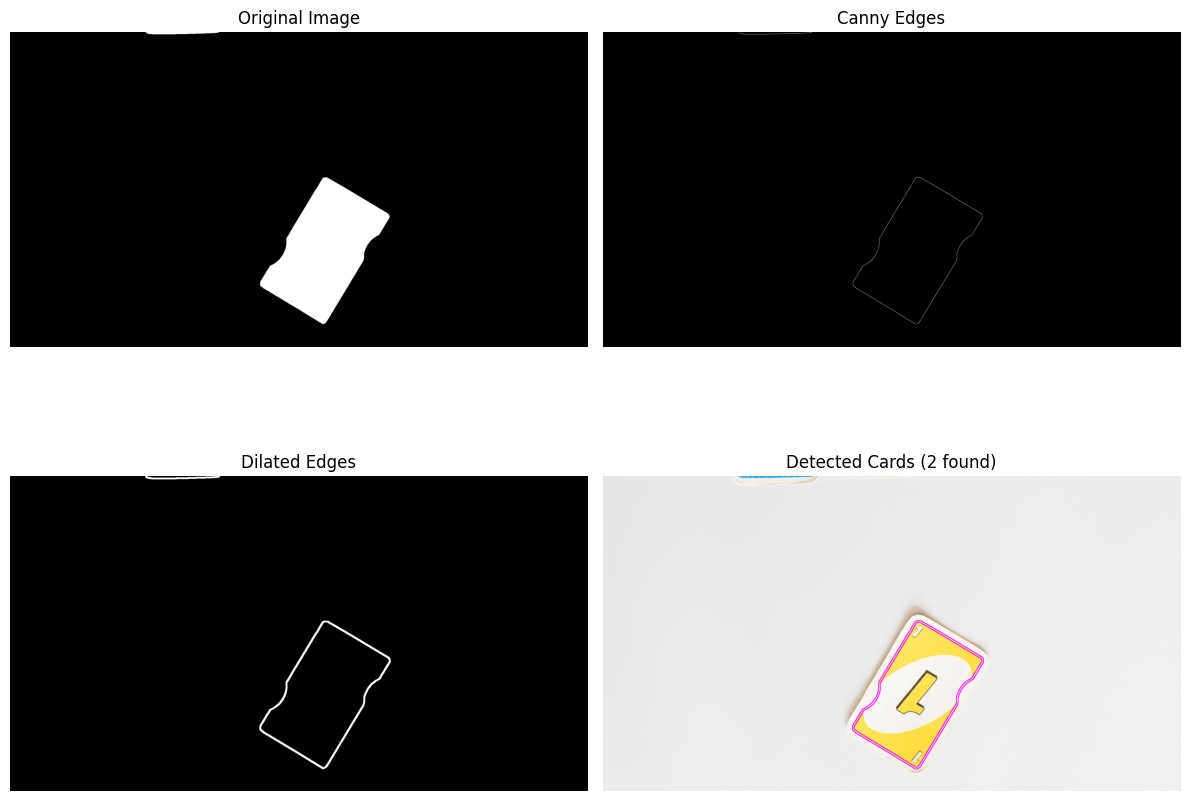

Detected 2 card contours


In [14]:
# Test card detection
hsv = cv2.cvtColor(sample_img, cv2.COLOR_RGB2HSV)
    
# Extract saturation channel (colored regions have high saturation)
saturation = hsv[:, :, 1]

# Threshold to find colored pixels
_, saturation_mask = cv2.threshold(saturation, 100, 255, cv2.THRESH_BINARY)

# Apply morphological operations to clean up
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
saturation_mask = cv2.morphologyEx(saturation_mask, cv2.MORPH_CLOSE, kernel)
saturation_mask = cv2.morphologyEx(saturation_mask, cv2.MORPH_OPEN, kernel, iterations=2)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (100, 100))
saturation_mask = cv2.morphologyEx(saturation_mask, cv2.MORPH_CLOSE, kernel, iterations=2)

# Convert back to RGB for compatibility
img_for_contours = cv2.cvtColor(saturation_mask, cv2.COLOR_GRAY2BGR)


valid_contours, edges, dilated = detect_card_contours(img_for_contours, 100000, 200000)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(img_for_contours)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis('off')

axes[0, 1].imshow(edges, cmap='gray')
axes[0, 1].set_title(f"Canny Edges")
axes[0, 1].axis('off')

axes[1, 0].imshow(dilated, cmap='gray')
axes[1, 0].set_title("Dilated Edges")
axes[1, 0].axis('off')

# Draw detected contours
img_contours = sample_img.copy()
cv2.drawContours(img_contours, valid_contours, -1, (255, 0, 255), 2)
axes[1, 1].imshow(img_contours)
axes[1, 1].set_title(f"Detected Cards ({len(valid_contours)} found)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print(f"Detected {len(valid_contours)} card contours")

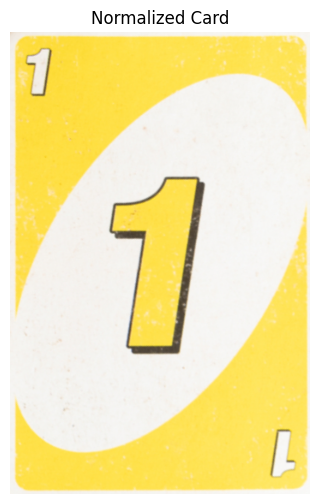

In [15]:
if len(valid_contours) > 0:
    normalized = extract_and_normalize_card(sample_img, valid_contours[0])
    plt.figure(figsize=(4, 6))
    plt.imshow(normalized)
    plt.axis('off')
    plt.title("Normalized Card")
    plt.show()


In [16]:
print(find_central_card(img))

(243.38461904761905, 231.36743915343916, 178.58311111111112)
y_PLACEHOLDER


In [9]:
find_active_player(img)

'p4'